# GlitchGAN Evaluation

Evaluates the **GlitchGAN** generator (TensorFlow/Keras, epoch 210) on LIGO gravitational-wave glitch data.

**Sections:**
1. Waveform visualisation — real vs generated signals
2. UMAP 3D embedding (correlation metric, 2 000 samples per class)
3. GravitySpy classification — inject generated glitches and classify with the O3 CNN

**Prerequisites:**
- Data files in `data/` (see README for download instructions)
- GravitySpy installed; set `PATH_TO_REPO` below to your local clone


In [108]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()
DATA_DIR     = PROJECT_ROOT / "data"
PLOTS_DIR    = PROJECT_ROOT / "evaluation_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

SEED = 56
os.environ["PYTHONHASHSEED"] = str(SEED)

sys.path.insert(0, str(PROJECT_ROOT / "src"))
from cdvgan.tf.model_components import ArgmaxLayer, ReduceSumDotLayer
_co = {"ArgmaxLayer": ArgmaxLayer, "ReduceSumDotLayer": ReduceSumDotLayer}

# ── Generator ─────────────────────────────────────────────────────────────────
GENERATOR_PATH  = PROJECT_ROOT / "weights" / "tensorflow" / "generator_210_keras3.keras"
GENERATOR_EPOCH = 210
NOISE_DIM       = 100
NUM_CLASSES     = 7
SAMPLES_PER_CLASS = 100

LABEL_ORDER = [
    "Blip", "Fast_Scattering", "Koi_Fish",
    "Low_Frequency_Burst", "Scattered_Light", "Tomte", "Whistle",
]

# ── GravitySpy ────────────────────────────────────────────────────────────────
IFO           = "H1"
SRATE         = 4096
GW_START      = 1262540000
GW_END        = GW_START + 40
CHANNEL       = f"{IFO}:GDS-CALIB_STRAIN"
PATH_TO_MODEL = PROJECT_ROOT / "models" / "sidd-cqg-paper-O3-model.h5"
# Update to your local GravitySpy repository clone:
PATH_TO_REPO  = "/path/to/GravitySpy"
NUM_CLASSIFY  = 100
SNR_TARGET    = 50
INIT_TIME     = -20
EVENT_TIME    = 0

print("Project root :", PROJECT_ROOT)
print("Generator    :", GENERATOR_PATH.name)
print("Model exists :", GENERATOR_PATH.exists())


Project root : /Users/tomdooney/Documents/Work/Projects/glitchgan
Generator    : generator_210_keras3.keras
Model exists : True


In [109]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import umap.umap_ as umap

try:
    import scienceplots
    plt.style.use(["science"])
except ImportError:
    pass  # scienceplots requires LaTeX; fall back to matplotlib defaults

import random
import tensorflow as tf

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 1. Load Data

In [110]:
X_real   = np.load(DATA_DIR / "glitch_GAN_samples_scaled_balanced.npy")
y_onehot = np.load(DATA_DIR / "glitch_GAN_labels_balanced.npy")
y_real   = np.array(LABEL_ORDER)[np.argmax(y_onehot, axis=1)]

print(f"Real signals : {X_real.shape}")
print(f"Classes      : {LABEL_ORDER}")


Real signals : (35000, 8192)
Classes      : ['Blip', 'Fast_Scattering', 'Koi_Fish', 'Low_Frequency_Burst', 'Scattered_Light', 'Tomte', 'Whistle']


## 2. Load Generator

In [111]:
import keras
from cdvgan.tf import GlitchGAN

gan = GlitchGAN()
gan.generator = keras.models.load_model(str(GENERATOR_PATH), compile=False)

print(f"Loaded GlitchGAN generator from: {GENERATOR_PATH.name}")


Loaded GlitchGAN generator from: generator_210_keras3.keras


## 3. Generate Signals

In [112]:
from cdvgan.tf.utils import generate_examples

X_fake, class_vecs = generate_examples(
    gan,
    noise_dim=NOISE_DIM,
    num_classes=NUM_CLASSES,
    num_signals=NUM_CLASSES * SAMPLES_PER_CLASS,
    sampling="vertex",
)
y_fake = np.array(LABEL_ORDER)[np.argmax(class_vecs, axis=1)]

print(f"Generated : {X_fake.shape}  ({SAMPLES_PER_CLASS} per class)")


Generated : (700, 8192)  (100 per class)


## 4. Waveform Visualisation

Loaded from cache: /Users/tomdooney/Documents/Work/Projects/glitchgan/evaluation_plots/strain_bg_1262540000_1262540040.hdf5
white_noise: (163840,)  type: <class 'numpy.ndarray'>


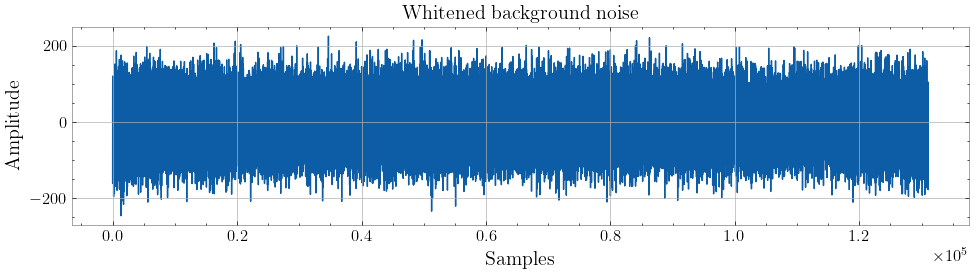

In [113]:
from gwpy.timeseries import TimeSeries
from pycbc.types import TimeSeries as PyCBCTimeSeries
import numpy as np
import matplotlib.pyplot as plt

_bg_cache = PROJECT_ROOT / "evaluation_plots" / f"strain_bg_{GW_START}_{GW_END}.hdf5"

try:
    strain_bg = TimeSeries.read(_bg_cache, format="hdf5")
    print(f"Loaded from cache: {_bg_cache}")
except Exception:
    strain_bg = TimeSeries.fetch_open_data("H1", GW_START, GW_END)
    strain_bg = strain_bg.resample(SRATE)
    strain_bg.write(_bg_cache, format="hdf5", overwrite=True)
    print(f"Fetched and cached: {_bg_cache}")

if hasattr(strain_bg, "delta_t"):
    strain_pycbc = strain_bg
else:
    strain_pycbc = PyCBCTimeSeries(
        np.asarray(strain_bg, dtype="float64"),
        delta_t=1.0 / SRATE,
        epoch=GW_START,
    )

white_noise, psd = strain_pycbc.whiten(
    len(strain_pycbc) / (2 * SRATE),
    len(strain_pycbc) / (4 * SRATE),
    remove_corrupted=False,
    return_psd=True,
)
# Convert to plain numpy array — prevents PyCBC epoch from being inherited
# by GWpyTimeSeries in the injection step, which would mis-place the event time.
white_noise = np.asarray(white_noise)
print(f"white_noise: {white_noise.shape}  type: {type(white_noise)}")

plt.figure(figsize=(10, 3))
plt.plot(white_noise[SRATE * 4 : -SRATE * 4])
plt.xlabel("Samples"); plt.ylabel("Amplitude")
plt.title("Whitened background noise")
plt.tight_layout(); plt.show()


/var/folders/gv/z_2s63x116vbz6s2hmnl7mkc0000gn/T/ipykernel_35743/118974187.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


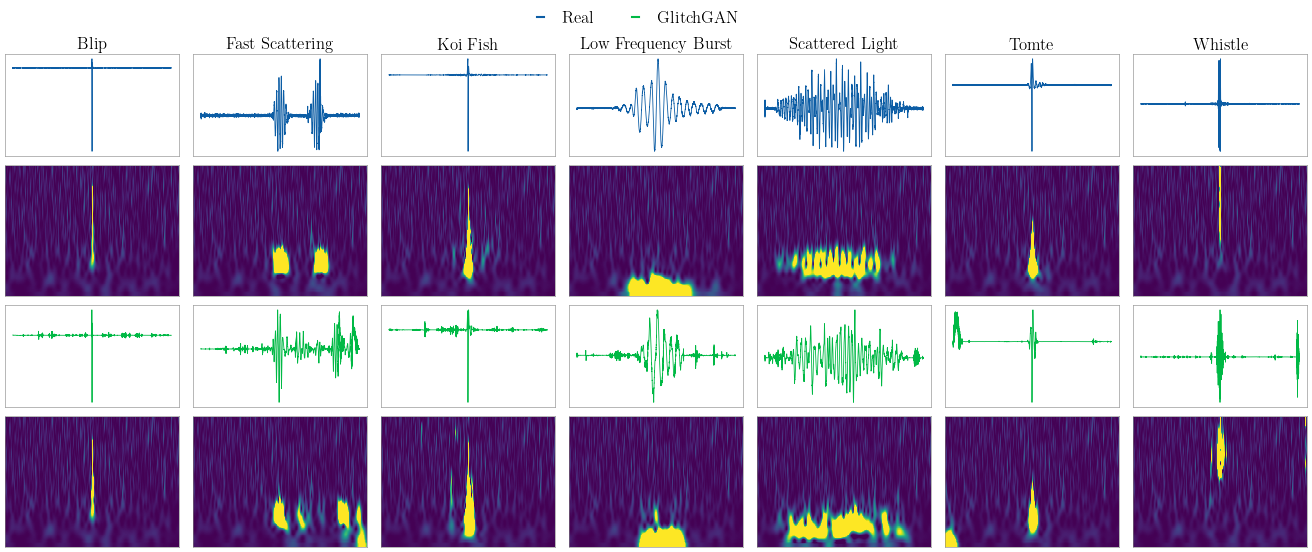

In [114]:
from matplotlib.lines import Line2D
from cdvgan.utils import plot_q_transform, whitened_snr_scaling

try:
    plt.style.use(["science"])
except Exception:
    pass

def _inject(glitch, white_noise):
    len_g    = len(glitch)
    id_start = len(white_noise) // 2 - len_g // 2
    injected = white_noise.copy()
    injected[id_start : id_start + len_g] += glitch
    return injected


def plot_comparison_grid(sources, label_order, n_examples=1, save_name=None,
                          white_noise=None, snr_default=50, snr_overrides=None):
    # Local RNG so sample selection is reproducible regardless of upstream state
    rng = np.random.default_rng(SEED)

    show_qscans    = white_noise is not None
    n_sources      = len(sources)
    n_classes      = len(label_order)
    rows_per_src   = 2 if show_qscans else 1
    n_rows         = n_sources * rows_per_src
    ts_height      = 1.4
    qs_height      = 1.8
    row_heights    = [ts_height, qs_height] * n_sources if show_qscans else [ts_height] * n_sources

    fig, axes = plt.subplots(
        n_rows, n_classes * n_examples,
        figsize=(2.4 * n_classes * n_examples, sum(row_heights)),
        gridspec_kw={"hspace": 0.08, "wspace": 0.08,
                     "height_ratios": row_heights},
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    legend_handles = []
    for src_idx, (X, y, src_label, color) in enumerate(sources):
        legend_handles.append(Line2D([0], [0], color=color, lw=1.5, label=src_label))
        ts_row = src_idx * rows_per_src
        qs_row = ts_row + 1 if show_qscans else None

        for ci, lbl in enumerate(label_order):
            idx    = np.where(y == lbl)[0]
            chosen = rng.choice(idx, min(n_examples, len(idx)), replace=False)
            snr    = (snr_overrides or {}).get(lbl, snr_default)

            for j, sample_idx in enumerate(chosen):
                col   = ci * n_examples + j
                ax_ts = axes[ts_row, col]

                ax_ts.plot(X[sample_idx], lw=0.6, color=color)
                ax_ts.set_xticks([]); ax_ts.set_yticks([])
                for spine in ax_ts.spines.values():
                    spine.set_linewidth(0.4)
                if src_idx == 0 and j == 0:
                    ax_ts.set_title(lbl.replace("_", " "), fontsize=12, pad=3)

                if show_qscans:
                    ax_qs    = axes[qs_row, col]
                    glitch   = whitened_snr_scaling(X[sample_idx], snr, srate=SRATE)
                    injected = _inject(glitch, white_noise)
                    plot_q_transform(injected, srate=SRATE, crop=(20, 2),
                                     whiten=False, ax=ax_qs, colourbar=False)
                    ax_qs.set_xlabel(""); ax_qs.set_ylabel("")
                    ax_qs.set_xticks([]); ax_qs.set_yticks([])
                    for spine in ax_qs.spines.values():
                        spine.set_linewidth(0.4)

    plt.tight_layout(rect=[0, 0, 1, 0.88])

    # Extra gap between source pairs (does not affect within-pair spacing)
    if show_qscans and n_sources > 1:
        for src_idx in range(1, n_sources):
            for row_offset in range(rows_per_src):
                row = src_idx * rows_per_src + row_offset
                for col in range(n_classes * n_examples):
                    pos = axes[row, col].get_position()
                    axes[row, col].set_position(
                        [pos.x0, pos.y0 - 0.04, pos.width, pos.height])

    fig.legend(handles=legend_handles, loc="upper center", ncol=n_sources,
               fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.97))
    if save_name:
        plt.savefig(PLOTS_DIR / f"{save_name}.pdf", bbox_inches="tight")
    plt.show()


plot_comparison_grid(
    sources=[
        (X_real, y_real, "Real",      "C0"),
        (X_fake, y_fake, "GlitchGAN", "C1"),
    ],
    label_order=LABEL_ORDER,
    n_examples=1,
    white_noise=white_noise,
    snr_default=50,
    snr_overrides={"Koi_Fish": 150, "Whistle": 150},
    save_name=f"waveform_comparison_ep{GENERATOR_EPOCH}",
)


## UMAP Embedding

3D UMAP embedding (correlation metric) of 2 000 real + 2 000 fake samples per class.
Reproduces Figures 5 & 6 from the paper.


In [73]:
import tensorflow as tf

N_FULL = 2000

# Subsample real data
rng_full = np.random.default_rng(42)
real_idx = []
for lbl in LABEL_ORDER:
    cls_idx = np.where(y_real == lbl)[0]
    real_idx.extend(rng_full.choice(cls_idx, size=min(N_FULL, len(cls_idx)), replace=False))
X_real_full = X_real[real_idx]
y_real_full  = y_real[real_idx]
print(f"Real subsampled : {X_real_full.shape}")

# Generate fake data in chunks (avoids OOM on large batch)
n_fake_full = NUM_CLASSES * N_FULL
noise_full  = np.random.randn(n_fake_full, NOISE_DIM).astype("float32")
class_full  = np.repeat(np.eye(NUM_CLASSES, dtype="float32"), N_FULL, axis=0)

CHUNK = 2048
chunks_fake = []
for i in range(0, n_fake_full, CHUNK):
    out = gan.generator([noise_full[i:i+CHUNK], class_full[i:i+CHUNK]], training=False)
    chunks_fake.append(out.numpy())
X_fake_full = np.concatenate(chunks_fake, axis=0)
y_fake_full  = np.repeat(LABEL_ORDER, N_FULL)
print(f"Fake generated  : {X_fake_full.shape}")

X_all_full         = np.concatenate([X_real_full, X_fake_full], axis=0)
y_all_full         = np.concatenate([y_real_full, y_fake_full], axis=0)
domain_labels_full = np.array(["Real"] * len(X_real_full) + ["Fake"] * len(X_fake_full))
print(f"UMAP input      : {X_all_full.shape}  ({X_all_full.nbytes / 1e9:.2f} GB)")


Real subsampled : (14000, 8192)
Fake generated  : (14000, 8192)
UMAP input      : (28000, 8192)  (1.84 GB)


In [74]:
reducer_full = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.6,
    metric="correlation",
    random_state=42,
    low_memory=True,
)
embedding_full_corr = reducer_full.fit_transform(X_all_full)
print(f"Embedding shape : {embedding_full_corr.shape}")


/opt/homebrew/Caskroom/miniforge/base/envs/cdvgan/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Embedding shape : (28000, 3)


In [75]:
low, high = 1, 99
x1, x2, x3 = embedding_full_corr[:, 0], embedding_full_corr[:, 1], embedding_full_corr[:, 2]
mask_clean = (
    (x1 >= np.percentile(x1, low))  & (x1 <= np.percentile(x1, high)) &
    (x2 >= np.percentile(x2, low))  & (x2 <= np.percentile(x2, high)) &
    (x3 >= np.percentile(x3, low))  & (x3 <= np.percentile(x3, high))
)
print(f"Removed {np.sum(~mask_clean)} outliers ({np.sum(~mask_clean)/len(mask_clean)*100:.2f}%)")

embedding_full_clean = embedding_full_corr[mask_clean]
y_all_clean          = y_all_full[mask_clean]
domain_labels_clean  = domain_labels_full[mask_clean]


Removed 1672 outliers (5.97%)


Saved: /Users/tomdooney/Documents/Work/Projects/glitchgan/evaluation_plots/umap_two_views_corr_2k.pdf


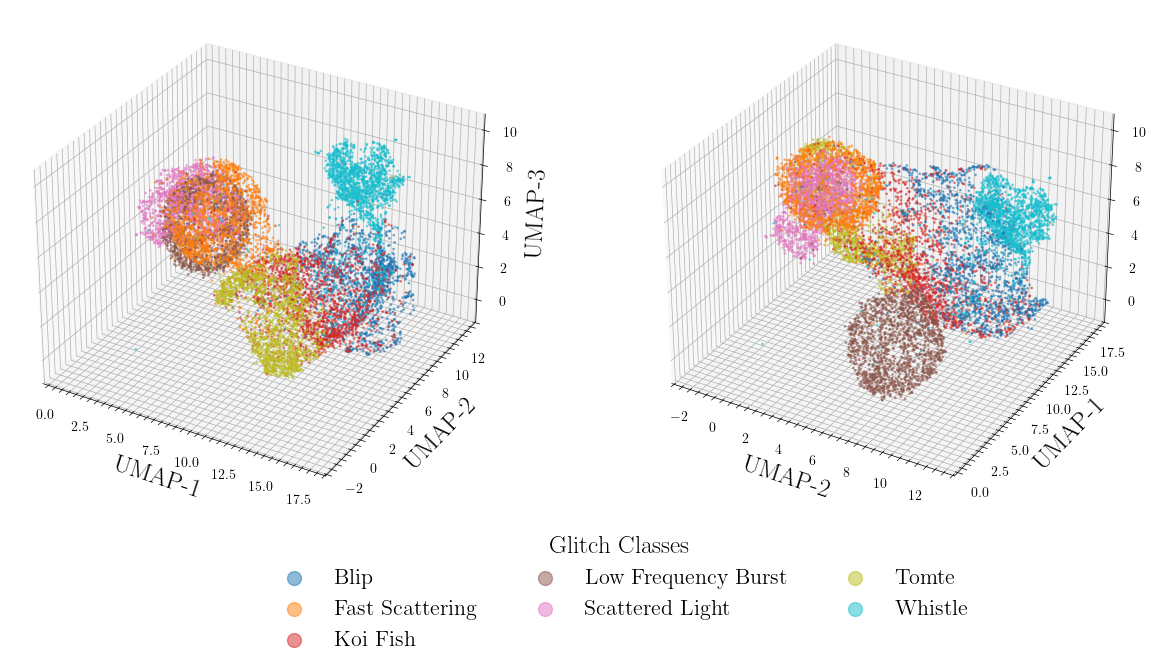

In [76]:
# ── Figure 5: two-view 3D UMAP ────────────────────────────────────────────────
from matplotlib.lines import Line2D

n_per_class = 800
plot_indices = []
for lbl in LABEL_ORDER:
    idx_real = np.where((y_all_clean == lbl) & (domain_labels_clean == "Real"))[0]
    idx_fake = np.where((y_all_clean == lbl) & (domain_labels_clean == "Fake"))[0]
    plot_indices.extend(np.random.choice(idx_real, min(len(idx_real), n_per_class), replace=False))
    plot_indices.extend(np.random.choice(idx_fake, min(len(idx_fake), n_per_class), replace=False))
plot_indices   = np.array(plot_indices)
embedding_plot = embedding_full_clean[plot_indices]
y_plot         = y_all_clean[plot_indices]
domain_plot    = domain_labels_clean[plot_indices]

unique_classes = np.array(LABEL_ORDER)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

for lbl, color in zip(unique_classes, colors):
    mask_real = (y_plot == lbl) & (domain_plot == "Real")
    mask_fake = (y_plot == lbl) & (domain_plot == "Fake")
    ax1.scatter(embedding_plot[mask_real, 0], embedding_plot[mask_real, 1], embedding_plot[mask_real, 2],
                c=[color], s=1, alpha=0.5, label=lbl.replace("_", " "))
    ax1.scatter(embedding_plot[mask_fake, 0], embedding_plot[mask_fake, 1], embedding_plot[mask_fake, 2],
                c=[color], s=1, alpha=0.5)
    ax2.scatter(embedding_plot[mask_real, 1], embedding_plot[mask_real, 0], embedding_plot[mask_real, 2],
                c=[color], s=1, alpha=0.5)
    ax2.scatter(embedding_plot[mask_fake, 1], embedding_plot[mask_fake, 0], embedding_plot[mask_fake, 2],
                c=[color], s=1, alpha=0.5)

ax1.set_xlabel("UMAP-1", fontsize=18); ax1.set_ylabel("UMAP-2", fontsize=18); ax1.set_zlabel("UMAP-3", fontsize=18)
ax2.set_xlabel("UMAP-2", fontsize=18); ax2.set_ylabel("UMAP-1", fontsize=18); ax2.set_zlabel("UMAP-3", fontsize=18)

handles, labels_leg = ax1.get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="lower center", ncol=len(unique_classes) // 2,
           fontsize=16, title="Glitch Classes", title_fontsize=18,
           frameon=False, bbox_to_anchor=(0.45, 0.02), markerscale=10)

plt.tight_layout(rect=[0, 0.12, 0.83, 1.3])
plt.subplots_adjust(wspace=0.25)
save_path = PLOTS_DIR / "umap_two_views_corr_2k.pdf"
plt.savefig(save_path, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()


Saved: /Users/tomdooney/Documents/Work/Projects/glitchgan/evaluation_plots/umap_per_class_corr_2k.pdf


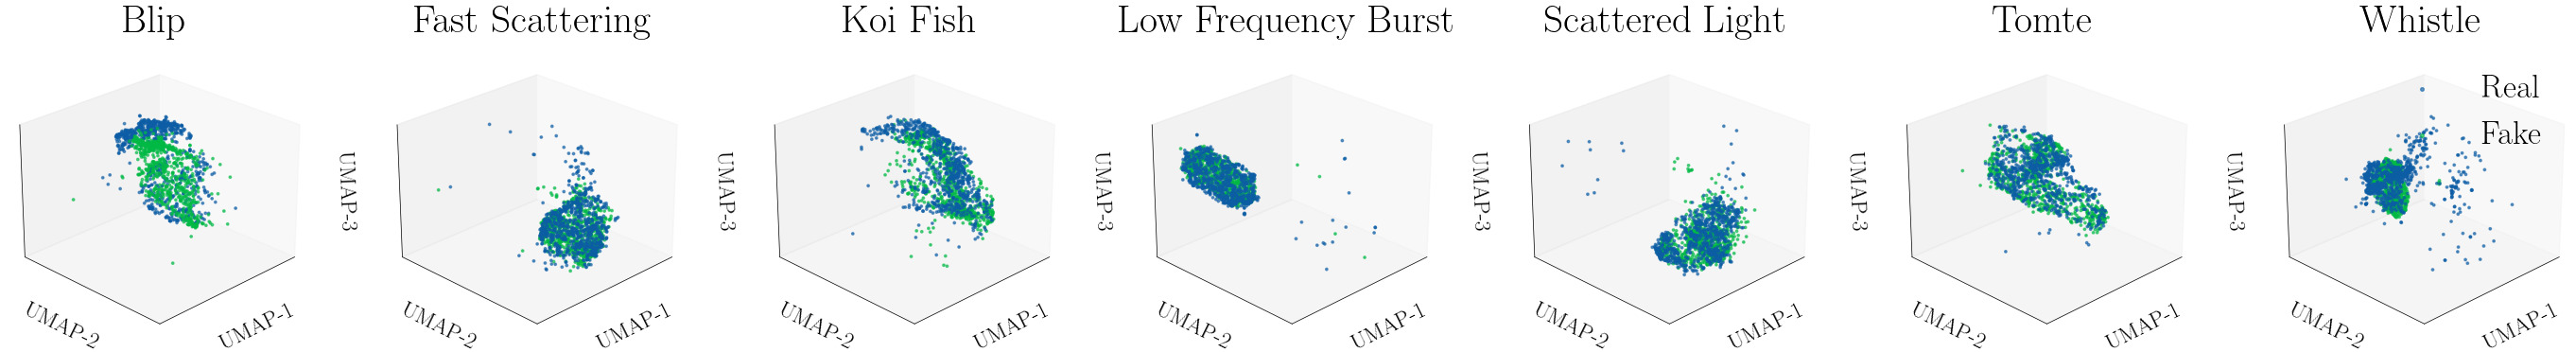

In [13]:
# ── Figure 6: per-class 3D UMAP ──────────────────────────────────────────────
fig = plt.figure(figsize=(4 * len(unique_classes), 5))

for i, lbl in enumerate(unique_classes):
    ax = fig.add_subplot(1, len(unique_classes), i + 1, projection="3d")
    mask_real = (y_plot == lbl) & (domain_plot == "Real")
    mask_fake = (y_plot == lbl) & (domain_plot == "Fake")
    ax.scatter(embedding_plot[mask_real, 0], embedding_plot[mask_real, 1], embedding_plot[mask_real, 2],
               c="C0", label="Real", s=3, alpha=0.6)
    ax.scatter(embedding_plot[mask_fake, 0], embedding_plot[mask_fake, 1], embedding_plot[mask_fake, 2],
               c="C1", label="Fake", s=3, alpha=0.6)
    ax.view_init(elev=25, azim=45)
    ax.set_xlabel("UMAP-1", fontsize=17, labelpad=2)
    ax.set_ylabel("UMAP-2", fontsize=17, labelpad=2)
    ax.set_zlabel("UMAP-3", fontsize=17, labelpad=2)
    ax.set_title(lbl.replace("_", " "), fontsize=30, pad=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    if i == len(unique_classes) - 1:
        ax.legend(fontsize=25, loc="upper right", markerscale=1.5, frameon=False)

plt.tight_layout(rect=[0.01, 0.01, 0.99, 1.1])
plt.subplots_adjust(wspace=0.25)
save_path = PLOTS_DIR / "umap_per_class_corr_2k.pdf"
plt.savefig(save_path, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()


## GravitySpy Classification

Injects GlitchGAN signals into whitened H1 background noise and classifies with the O3 CNN.

Each signal is scaled to SNR ≈ 50 and injected at the midpoint of a 40 s whitened background segment.
GravitySpy classifies via a Q-transform followed by the O3 CNN (`sidd-cqg-paper-O3-model.h5`).


In [14]:
# white_noise already loaded in section 4 above — reuse it here.
print(f'white_noise: {white_noise.shape}')


In [15]:
import sys, warnings, logging, io
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm
from gwpy.timeseries import TimeSeries as GWpyTimeSeries
from gravityspy.classify import classify
from cdvgan.utils import whitened_snr_scaling
from IPython.display import Image as IPyImage, display as ipy_display

warnings.filterwarnings("ignore")
logging.getLogger("gravityspy").setLevel(logging.ERROR)
logging.getLogger("gwpy").setLevel(logging.ERROR)
logging.getLogger("astropy").setLevel(logging.ERROR)
logging.getLogger("tensorflow").setLevel(logging.ERROR)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

sys.path.insert(0, PATH_TO_REPO)


def _inject_and_wrap(glitch, white_noise):
    len_glitch = len(glitch)
    id_start   = len(white_noise) // 2 - len_glitch // 2
    injected   = white_noise.copy()
    injected[id_start : id_start + len_glitch] += glitch
    return GWpyTimeSeries(injected, t0=INIT_TIME, sample_rate=SRATE, name=CHANNEL)


def classify_signals(X_gen, y_gen, label_order, tag):
    rows = []
    _prev = plt.get_backend()
    plt.switch_backend("agg")
    try:
        total = NUM_CLASSIFY * len(label_order)
        with tqdm(total=total, desc=f"Classifying [{tag}]", unit="glitch") as pbar:
            for lbl in label_order:
                cls_idx = np.where(y_gen == lbl)[0]
                chosen  = np.random.choice(cls_idx, min(NUM_CLASSIFY, len(cls_idx)), replace=False)
                for i in chosen:
                    glitch    = whitened_snr_scaling(X_gen[i], SNR_TARGET, srate=SRATE)
                    glitch_ts = _inject_and_wrap(glitch, white_noise)
                    try:
                        with warnings.catch_warnings():
                            warnings.simplefilter("ignore")
                            result = classify(EVENT_TIME, CHANNEL, str(PATH_TO_MODEL),
                                              timeseries=glitch_ts)
                        rows.append({
                            "true_label": lbl,
                            "pred_label": result["ml_label"].value[0],
                            "confidence": result["ml_confidence"].value[0],
                        })
                    except Exception:
                        rows.append({"true_label": lbl, "pred_label": "Error", "confidence": 0.0})
                    pbar.update(1)
    finally:
        plt.switch_backend(_prev)
    return pd.DataFrame(rows)


def plot_confusion(df, tag, save_name):
    if df is None or len(df) == 0:
        print(f"No results for {tag}")
        return None
    df = df[df["pred_label"] != "Error"]

    pred_all = sorted(df["pred_label"].unique())
    for lbl in LABEL_ORDER:
        if lbl not in pred_all:
            pred_all.append(lbl)
    pred_cols = (
        [lbl for lbl in LABEL_ORDER if lbl in pred_all]
        + [lbl for lbl in pred_all if lbl not in LABEL_ORDER]
    )

    count_matrix = pd.DataFrame(0, index=LABEL_ORDER, columns=pred_cols)
    conf_accum   = {(t, p): [] for t in LABEL_ORDER for p in pred_cols}
    for t, p, c in zip(df["true_label"], df["pred_label"], df["confidence"]):
        if t in LABEL_ORDER and p in pred_cols:
            count_matrix.loc[t, p] += 1
            conf_accum[(t, p)].append(c)

    annot = pd.DataFrame("", index=LABEL_ORDER, columns=pred_cols)
    for t in LABEL_ORDER:
        for p in pred_cols:
            n = count_matrix.loc[t, p]
            if n == 0:
                annot.loc[t, p] = "0"
            else:
                m = np.mean(conf_accum[(t, p)])
                annot.loc[t, p] = f"{n}\n({m:.2f})"

    acc = np.trace(count_matrix.values) / count_matrix.values.sum()

    fig_w = max(10, len(pred_cols) * 1.1)
    sns.set(style="whitegrid", font_scale=1.0)
    fig, ax = plt.subplots(figsize=(fig_w, 6))
    sns.heatmap(count_matrix, annot=annot, fmt="", cmap="Blues", cbar=True,
                linewidths=0.5, linecolor="gray", annot_kws={"size": 8, "color": "black"}, ax=ax)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title(f"Gravity Spy — {tag}   (accuracy = {acc:.1%})", fontsize=13)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / f"{save_name}.pdf", bbox_inches="tight")
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    ipy_display(IPyImage(buf.read()))
    print(f"{tag} accuracy: {acc:.3f}")
    return acc


INFO:panoptes_client:libmagic not operational, likely due to lack of shared libraries. Media MIME type determination will be based on file extensions.


### Classify

In [ ]:
# Generate balanced vertex samples for GravitySpy classification
class_vectors = np.repeat(np.eye(NUM_CLASSES, dtype="float32"), NUM_CLASSIFY, axis=0)
noise_gspy    = np.random.randn(NUM_CLASSES * NUM_CLASSIFY, NOISE_DIM).astype("float32")
X_gspy = gan.generator([noise_gspy, class_vectors], training=False).numpy()
y_gspy = np.repeat(np.array(LABEL_ORDER), NUM_CLASSIFY)
print(f"Generated: {X_gspy.shape}  ({NUM_CLASSIFY} per class)")

df = classify_signals(X_gspy, y_gspy, LABEL_ORDER, "GlitchGAN (epoch 210)")
df.to_csv(PLOTS_DIR / "gspy_results_keras3.csv", index=False)
print(f"Saved CSV: {PLOTS_DIR / 'gspy_results_keras3.csv'}")

acc = plot_confusion(df, "GlitchGAN (epoch 210)", "gspy_cm_keras3")


Generated: (700, 8192)  (100 per class)


Classifying [GlitchGAN (epoch 210)]:   0%|          | 0/700 [00:00<?, ?glitch/s]